In [126]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [75]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [76]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [77]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [78]:
print(sentiment.shape[1])
print(trades.shape[1])

4
16


In [79]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [80]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [81]:
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'])
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

In [82]:
sentiment['date'] = sentiment['timestamp'].dt.date
trades['date'] = trades['Timestamp'].dt.date

In [83]:
daily_pnl = trades.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.rename(columns={'Closed PnL': 'daily_pnl'}, inplace=True)
daily_pnl.head()

,Account,date,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,4.788532e+04
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,-7.043619e+04
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,1.324648e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,1.686580e+05


In [84]:
traders_per_day = trades.groupby(['Account', 'date']).size().reset_index(name='num_traders')

In [85]:
avg_trader_size=trades.groupby(['Account', 'date'])['Size USD'].mean().reset_index(name='avg_trader_size')
avg_trader_size.rename(columns={'Size USD': 'avg_trader_size'}, inplace=True)
avg_trader_size.head()

,Account,date,avg_trader_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,3138.894782


In [86]:
trades['win']=trades['Closed PnL'] > 0
win_rate=trades.groupby(['Account', 'date'])['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)
win_rate.head()

,Account,date,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,0.519914


In [87]:
metrics = daily_pnl.merge(traders_per_day, on=['Account', 'date'], how='left')
metrics = metrics.merge(avg_trader_size, on=['Account', 'date'], how='left')
metrics = metrics.merge(win_rate, on=['Account', 'date'], how='left')
metrics.head()

,Account,date,daily_pnl,num_traders,avg_trader_size,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,4.788532e+04,7280,1653.226327,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,-7.043619e+04,3809,8893.000898,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,1.324648e+05,13311,507.626933,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,1.686580e+05,3239,3138.894782,0.519914


In [88]:
data=metrics.merge(sentiment[['date', 'classification']], on='date', how='left')
data.head()

,Account,date,daily_pnl,num_traders,avg_trader_size,win_rate,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.359612,Fear
1,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.359612,Extreme Fear
2,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.359612,Fear
3,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.359612,Extreme Fear
4,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.359612,Extreme Fear


In [89]:
pnl_sentiment=data.groupby('classification')['daily_pnl'].mean().reset_index()
pnl_sentiment

,classification,daily_pnl
0,Extreme Fear,321779.966982
1,Extreme Greed,321779.966982
2,Fear,321779.966982
3,Greed,321779.966982
4,Neutral,321779.966982


Text(0, 0.5, 'Average Daily PnL')

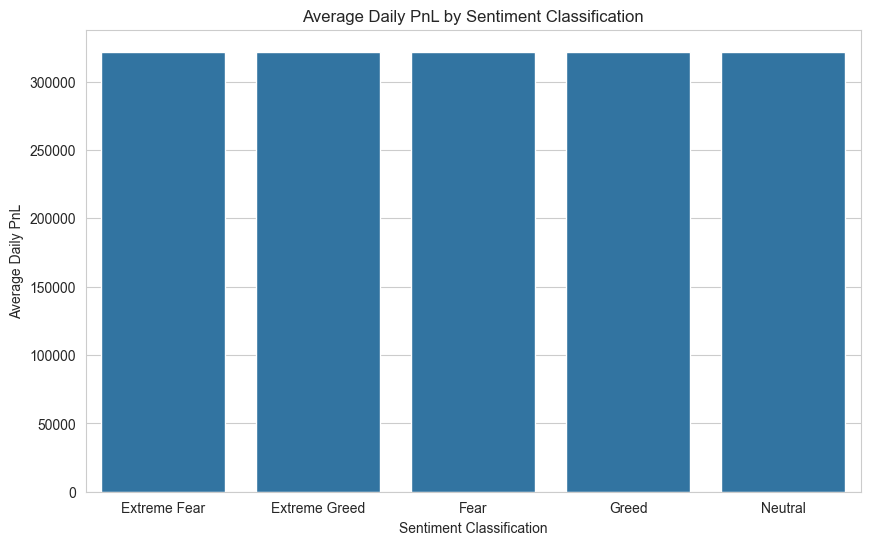

In [92]:
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='daily_pnl', data=pnl_sentiment)
plt.title('Average Daily PnL by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Daily PnL')


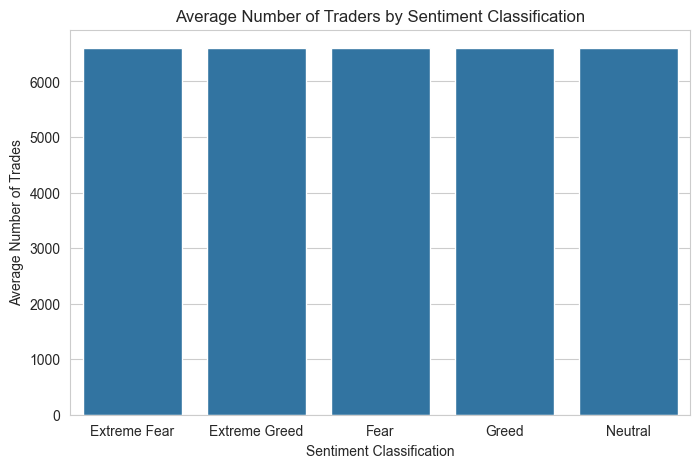

In [95]:
time_freq=data.groupby('classification')['num_traders'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='classification', y='num_traders', data=time_freq)
plt.title('Average Number of Traders by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Number of Trades')
plt.show()

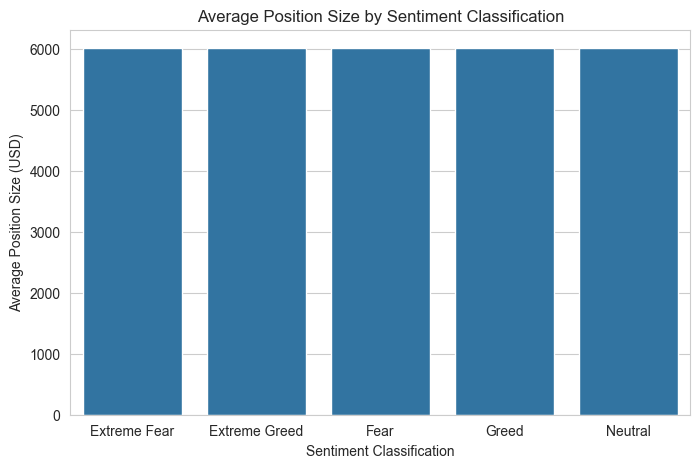

In [111]:
position_size=data.groupby('classification')['avg_trader_size'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='classification', y='avg_trader_size', data=position_size)
plt.title('Average Position Size by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Position Size (USD)')
plt.show()

In [114]:
data['trade_segment']=np.where(data['avg_trader_size'] > data['avg_trader_size'].median(), 'Frequent Trader', 'Not Frequent Trader')
segment_pnl=data.groupby('trade_segment')['daily_pnl'].mean().reset_index()

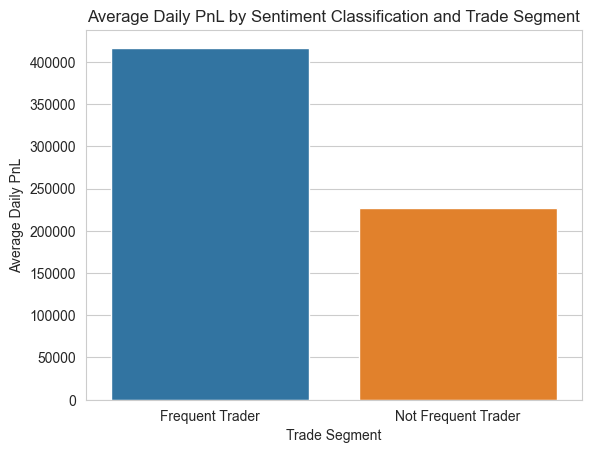

In [115]:
sns.barplot(x='trade_segment', y='daily_pnl', hue='trade_segment', data=segment_pnl)
plt.title('Average Daily PnL by Sentiment Classification and Trade Segment')
plt.xlabel('Trade Segment')
plt.ylabel('Average Daily PnL')
plt.show()

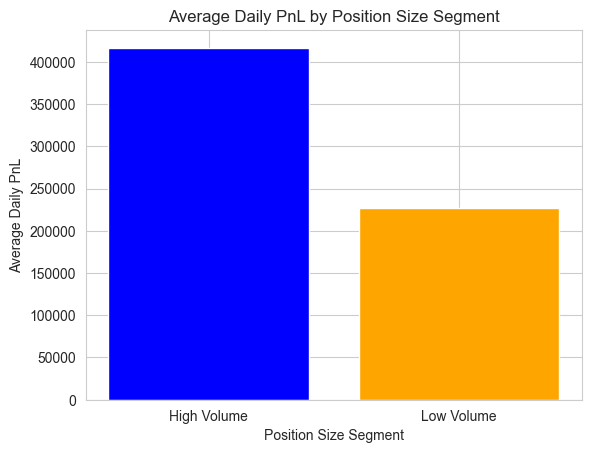

In [120]:
data['size_segment']=np.where(data['avg_trader_size'] > data['avg_trader_size'].median(), 'High Volume', 'Low Volume')
size_segment_pnl=data.groupby('size_segment')['daily_pnl'].mean().reset_index()
plt.bar(size_segment_pnl['size_segment'], size_segment_pnl['daily_pnl'], color=['blue', 'orange'])
plt.title('Average Daily PnL by Position Size Segment')
plt.xlabel('Position Size Segment')
plt.ylabel('Average Daily PnL')
plt.show()

In [122]:
data['Profitability']=np.where(data['daily_pnl'] > 0, 'Profitable', 'Not Profitable')

In [123]:
sentiment_map={'Extreme Fear': 0, 'Fear': 1, 'Neutral': 2, 'Greed': 3, 'Extreme Greed': 4}
data['sentiment_score']=data['classification'].map(sentiment_map)

In [124]:
features=data[['sentiment_score', 'num_traders', 'avg_trader_size', 'win_rate']]
target=data['Profitability']

In [125]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [127]:
model=RandomForestClassifier(n_estimators=100)
model.fit(x_train, y_train)

RandomForestClassifier()

In [128]:
pred=model.predict(x_test)
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred))

                precision    recall  f1-score   support

Not Profitable       1.00      1.00      1.00      1569
    Profitable       1.00      1.00      1.00     15353

      accuracy                           1.00     16922
     macro avg       1.00      1.00      1.00     16922
  weighted avg       1.00      1.00      1.00     16922

[[ 1569     0]
 [    0 15353]]
Accuracy: 1.0


In [130]:
cluster_features=data[['sentiment_score', 'num_traders', 'avg_trader_size', 'win_rate']]
scaler=StandardScaler()
scaled_features=scaler.fit_transform(cluster_features)
kmeans=KMeans(n_clusters=3, random_state=42)

In [131]:
data['trade_cluster']=kmeans.fit_predict(scaled_features)

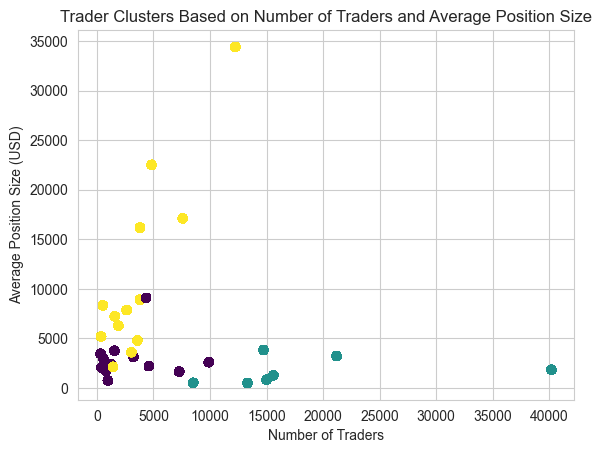

In [134]:
plt.scatter(data['num_traders'], data['avg_trader_size'], c=data['trade_cluster'], cmap='viridis')
plt.title('Trader Clusters Based on Number of Traders and Average Position Size')
plt.xlabel('Number of Traders')
plt.ylabel('Average Position Size (USD)')
plt.show()

In [135]:
data.to_csv("processed_trader_sentiment_data.csv", index=False)

In [137]:
print(data.groupby('classification')['daily_pnl'].mean())

print(data.groupby('classification')['num_traders'].mean())

classification
Extreme Fear     321779.966982
Extreme Greed    321779.966982
Fear             321779.966982
Greed            321779.966982
Neutral          321779.966982
Name: daily_pnl, dtype: float64
classification
Extreme Fear     6600.75
Extreme Greed    6600.75
Fear             6600.75
Greed            6600.75
Neutral          6600.75
Name: num_traders, dtype: float64
